<a href="https://colab.research.google.com/github/grupos4g4/PROJAPLIC4/blob/main/cd_projeto_aplicado_iv_entrega_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2025/02**


# **Entrega 4**

---

# **Sinais da Educação Superior (2014–2024): análise de séries temporais de ingressos e matrículas por modalidade no Brasil**
---

In [ ]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Anderson Aparecido da Silva Alves, 10347602' #@param {type:"string"}
Aluno2 = 'Andreia Domingos dos Santos, 10288503' #@param {type:"string"}
Aluno3 = 'Gerson Soares Rodrigues, 10423804' #@param {type:"string"}
Aluno4 = 'Samuel Bonfim da Silva, 10423569' #@param {type:"string"}


# **Resumo**

Este trabalho apresenta a quarta etapa do Projeto Aplicado IV, cujo objetivo é modelar e prever a taxa de evasão de cursos de educação superior no Brasil utilizando dados do Censo da Educação Superior (INEP). Após a consolidação da base de dados, realizamos uma análise exploratória detalhada (EDA), destacando padrões por ano e modalidade (presencial/EaD). Em seguida, desenvolvemos um modelo preditivo baseado em redes neurais recorrentes do tipo LSTM, incorporando embeddings para variáveis categóricas e séries temporais anuais entre 2014 e 2024. Os resultados indicam que o modelo é capaz de capturar tendências estruturais da evasão, especialmente o comportamento crescente na modalidade EaD. Também avaliamos a capacidade preditiva na base de teste (2023–2024) e realizamos uma extrapolação exploratória para os anos subsequentes. Os achados reforçam a utilidade de técnicas de deep learning na compreensão de dinâmicas educacionais e sugerem caminhos de aprimoramento para pesquisas futuras.

# **Introdução**

A educação superior brasileira tem passado, entre 2014 e 2024, por mudanças estruturais que afetam diretamente os padrões de matrícula, permanência e conclusão dos estudantes. Entre essas transformações destacam-se a expansão acelerada da modalidade a distância (EaD), o processo de recomposição das matrículas após a pandemia de COVID-19 e ajustes na rede de instituições e cursos. O Censo da Educação Superior, produzido anualmente pelo Instituto Nacional de Estudos e Pesquisas (Inep), é a principal fonte para acompanhar essas dinâmicas, oferecendo dados essenciais para análises acadêmicas, planejamento institucional e formulação de políticas públicas (BRASIL, 2024). Relatórios complementares, como o Censo EAD.BR 2023/2024, também evidenciam que práticas de gestão, mediação pedagógica e uso de tecnologias influenciam diretamente a permanência dos estudantes, especialmente na modalidade EaD (ABED, 2024). Além disso, estudos nacionais e internacionais reforçam que a evasão resulta de múltiplos fatores e que modelos preditivos podem apoiar intervenções mais precisas (OLIVEIRA et al., 2021; TAMADA, 2022; NGUYEN THI CAM; SARLAN; ARSHAD, 2024; TALEBI; TORABI; DANESHPOUR, 2024; VOGHOEI et al., 2023; SEMESP, 2025).

Esse contexto motivou o desenvolvimento do presente trabalho, cujo objetivo geral é analisar tendências e projeções da taxa de evasão no ensino superior brasileiro utilizando séries históricas derivadas dos microdados do Censo da Educação Superior no período de 2014 a 2024, com aplicação de técnicas de aprendizado profundo, especialmente redes LSTM. Para atingir esse propósito, o estudo compreende etapas integradas que incluem: a consolidação e preparação da base anual contendo matrículas, ingressantes, concluintes e situações acadêmicas; o cálculo da taxa de evasão por curso e modalidade; a realização de análise exploratória (EDA) para identificação de padrões e rupturas; a estruturação de janelas temporais adequadas ao modelo; e o treinamento, avaliação e interpretação de um modelo LSTM com embeddings para variáveis categóricas, capaz de gerar previsões a partir do comportamento histórico das séries.

A base de dados utilizada — dataset_inep.csv — foi construída a partir dos microdados oficiais do Inep, englobando informações agregadas por ano, instituição, curso e modalidade entre 2014 e 2024. Essa organização possibilita análises consistentes e reprodutíveis, além de subsidiar a modelagem temporal necessária para capturar tendências da evasão no período.

A justificativa para este estudo reside tanto na relevância técnica quanto na relevância social do tema. Do ponto de vista técnico, o trabalho aplica conceitos e métodos discutidos no componente curricular, envolvendo pré-processamento, análise exploratória e modelagem preditiva com redes neurais recorrentes, em consonância com a literatura recente sobre predição de evasão (NGUYEN THI CAM; SARLAN; ARSHAD, 2024; TALEBI; TORABI; DANESHPOUR, 2024). No plano social, a construção de diagnósticos quantitativos e projeções a partir de dados oficiais permite identificar padrões críticos, apoiar decisões institucionais e contribuir para políticas mais eficazes de permanência estudantil. Ao integrar análise estatística, técnicas de inteligência artificial e dados públicos de larga escala, o estudo busca apoiar o enfrentamento da evasão e promover uma gestão educacional mais eficiente e alinhada às necessidades contemporâneas do sistema de ensino superior (ABED, 2024; SEMESP, 2025).

# **Referencial Teórico**

(1 página) Defir resumidamente os principais conceitos envolvidos na sua A evasão no ensino superior é um fenômeno com diversos fatores, influenciado por condições socioeconômicas, fatores institucionais, características pedagógicas, engajamento acadêmico e perfil dos estudantes. Estudos apontam que a evasão tende a ocorrer quando há ruptura na trajetória formativa, falta de suporte institucional ou dificuldades de adaptação ao modelo pedagógico — especialmente na modalidade a distância, onde aspectos como motivação e autonomia exercem papel determinante (OLIVEIRA et al., 2021). Nesse contexto, o acompanhamento sistemático das taxas de evasão e a construção de modelos capazes de identificar padrões temporais tornam-se estratégias importantes para subsidiar políticas de permanência.

No campo da Ciência de Dados aplicada à educação, diferentes abordagens têm sido empregadas para previsão ou detecção precoce de evasão. Métodos estatísticos tradicionais, como regressão linear e modelos ARIMA, já foram amplamente utilizados em séries históricas de indicadores educacionais, mas apresentam limitações quando há padrões não lineares, mudanças estruturais ou forte dependência temporal (TAMADA, 2022). Em ambientes de ensino online, modelos supervisionados como Random Forest, Gradient Boosting e SVM vêm sendo aplicados para classificar estudantes em risco de evasão, mas sua capacidade de capturar relações sequenciais entre eventos ou anos é limitada (VOGHOEI et al., 2023).

Com o avanço do aprendizado profundo, modelos de redes neurais recorrentes (RNNs) — especialmente as Long Short-Term Memory (LSTM) — passaram a ser amplamente empregados para análise temporal da evasão educacional. As LSTMs são capazes de reter informações de longo prazo por meio de seus mecanismos internos de memória, superando limitações de RNNs tradicionais. Nguyen Thi Cam, Sarlan e Arshad (2024), por exemplo, propuseram um modelo híbrido que integra LSTMs com máquinas de vetor de suporte semissupervisionadas para identificar risco de evasão, demonstrando maior precisão em comparação a abordagens puramente supervisionadas. Em outro estudo relevante, Talebi, Torabi e Daneshpour (2024) utilizaram modelos ensemble combinando CNN e LSTM para previsão de evasão em cursos massivos (MOOCs), reforçando que modelos híbridos tendem a capturar tanto padrões temporais quanto características contextuais do estudante.

Embora essas abordagens mostrem alto desempenho, algumas limitações são recorrentes: necessidade de bases históricas extensas, dificuldade de interpretação dos resultados e sensibilidade a dados faltantes ou desbalanceados. Além disso, a maior parte dos trabalhos internacionais concentra-se em ambientes de plataformas digitais de aprendizagem, cuja granularidade de dados (logs, interações, tempo de acesso) difere do contexto brasileiro baseado em microdados educacionais anuais.

Nesse sentido, aplica-se neste estudo uma solução alinhada às tendências contemporâneas do campo: modelos LSTM para previsão de séries temporais baseadas em indicadores anuais de evasão. O uso de embeddings para variáveis categóricas — tais como modalidade, tipo de instituição e região — permite que o modelo represente características estruturais da educação superior brasileira de forma eficiente e não esparsa. Essa abordagem junta a força das LSTMs para lidar com dependências ao longo do tempo, com uma maior capacidade de entender o significado das variáveis institucionais, tornando o modelo mais expressivo.

Em comparação com alternativas tradicionais (ETS, ARIMA e regressões lineares), modelos baseados em aprendizado profundo apresentam vantagens ao lidar com relações não lineares, múltiplas dimensões e padrões temporais complexos. Por outro lado, exigem maior poder computacional, apresentam menor interpretabilidade e requerem maior cuidado no pré-processamento da base. Ainda assim, conforme apontam as análises setoriais do Censo da Educação Superior (BRASIL, 2024), do Censo EAD.BR (ABED, 2024) e do Mapa do Ensino Superior no Brasil (SEMESP, 2025), a necessidade de modelos mais robustos para compreensão da evasão é crescente, o que reforça a validade da abordagem adotada.

Dessa forma, este trabalho destaca a relevância de técnicas modernas de predição baseadas em séries temporais e aprendizado profundo, evidenciando que a adoção de modelos LSTM representa uma alternativa adequada para capturar tendências da evasão no ensino superior brasileiro no período de 2014 a 2024.



# **Diagrama de Solução**

O processo desenvolvido para previsão da taxa de evasão no ensino superior, considerando o período de 2014 a 2024, foi estruturado em um pipeline composto por etapas sequenciais e interdependentes. O objetivo é transformar os microdados brutos do Censo da Educação Superior em séries temporais consistentes e, a partir delas, treinar um modelo baseado em redes neurais LSTM capaz de antecipar padrões de evasão. A seguir, apresenta-se o fluxo completo da solução implementada.

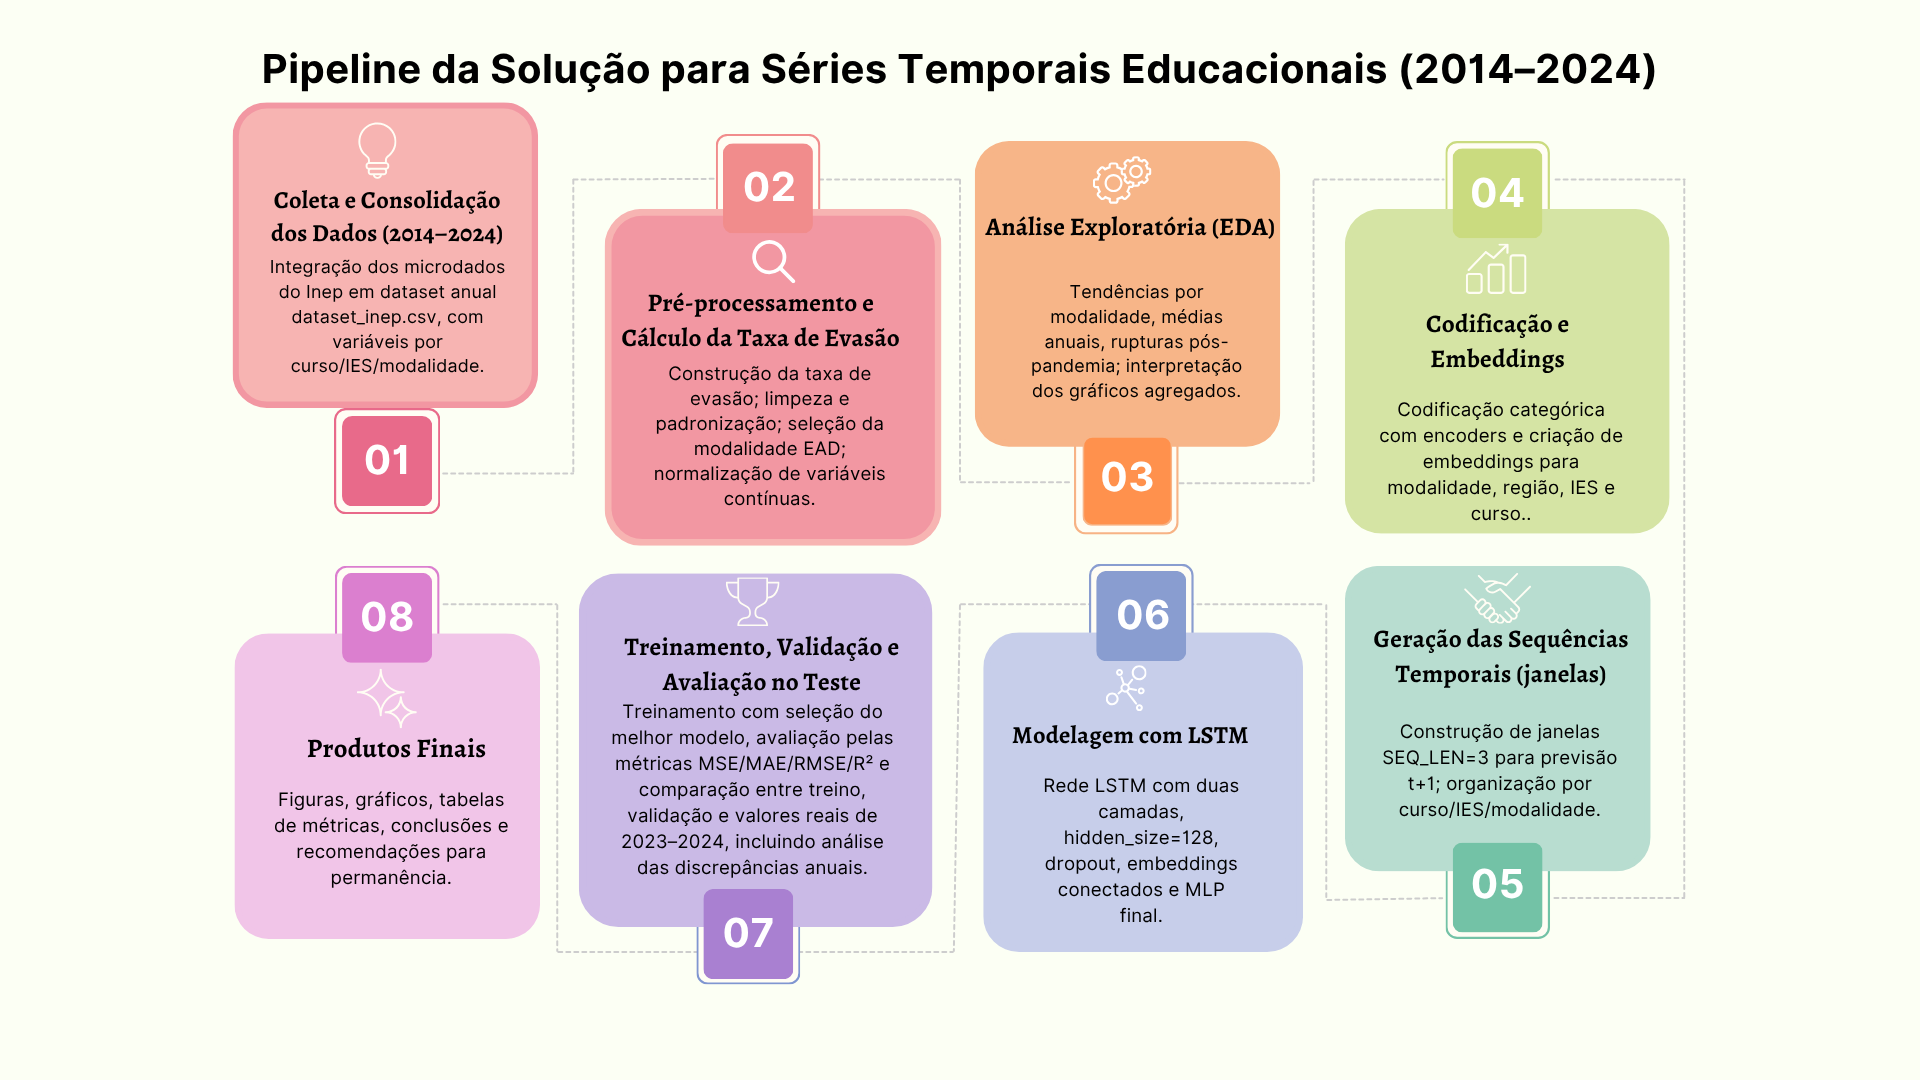

## 1. Coleta e Consolidação dos Dados ##

Os microdados oficiais do Inep são integrados e organizados no arquivo consolidado dataset_inep.csv, contendo informações anuais por curso, instituição e modalidade. Nessa etapa, são selecionadas variáveis essenciais (matrículas, ingressantes, concluintes e situações acadêmicas) e estruturados os dados de forma padronizada e consistente para permitir análises temporais confiáveis.

## 2. Pré-processamento e Cálculo da Taxa de Evasão ##

As variáveis de situação acadêmica (trancamento, desligamento, transferência e óbito) são agregadas para compor a evasão total. Em seguida, calcula-se a taxa de evasão como proporção entre evasão total e matrículas válidas. Registros inconsistentes, como aqueles com matrículas iguais a zero, são removidos. A base também passa por limpeza, padronização e filtragem da modalidade EAD, além de normalização das variáveis contínuas quando necessário.

## 3. Análise Exploratória (EDA) ##

Esta etapa inclui análise interpretativa dos gráficos gerados. São examinadas tendências anuais por modalidade, médias agregadas, possíveis rupturas no período pós-pandemia e diferenças estruturais entre EaD e presencial. Essa análise fundamenta a compreensão dos padrões que o modelo deverá captar e ajuda a validar a coerência dos dados antes da modelagem.

## 04. Codificação e Embeddings ##

As variáveis categóricas (modalidade, tipo de instituição, região, organização acadêmica, entre outras) são transformadas por meio de encoders e posteriormente representadas em vetores densos usando embeddings. Essa abordagem melhora a capacidade do modelo de captar características institucionais e reduz a esparsidade que ocorreria com métodos tradicionais de codificação.

## 05. Geração das Sequências Temporais (Janelas) ##

A base é ordenada por curso/IES/modalidade e ano, e são construídas janelas temporais do tipo sliding window com tamanho fixo (SEQ_LEN = 3). Cada janela representa um trecho da série histórica, sendo o último valor a variável alvo empregada na previsão t+1. Essa etapa prepara adequadamente os dados para utilização na rede LSTM e mantém a coerência temporal.

## 06. Modelagem com LSTM ##

A arquitetura implementada integra os embeddings das variáveis categóricas com variáveis contínuas padronizadas, alimentando uma rede LSTM composta por duas camadas, hidden_size = 128 e dropout ajustado. Após a LSTM, uma MLP final realiza a regressão da taxa prevista. Essa arquitetura atende à recomendação do professor de aumentar a profundidade do modelo e ajustar o número de unidades.

## 07. Treinamento, Validação e Avaliação no Teste ##

O modelo é treinado com o otimizador Adam e função de perda MSE. O melhor modelo é salvo via checkpoint. Métricas como MSE, MAE, RMSE e R² são acompanhadas para avaliar o desempenho nas etapas de treino e validação. Após o treinamento, o modelo é aplicado à base de teste (2023–2024), permitindo comparar valores reais e previstos, identificar discrepâncias e analisar o comportamento agregado por ano.

## 08. Produtos Finais ##

A etapa final consolida métricas, gráficos, tabelas e interpretações dos resultados, incluindo comparações Real × Previsto e sínteses visuais. Esses produtos sustentam a discussão sobre tendências, limitações, impactos e recomendações práticas relacionadas à evasão, além de orientar decisões para ações de permanência estudantil.

# **EDA e Pré-processamento dos dados**

(Exploração, discussão da base, preparação, limpeza, transformações, encoders, normalização e janelas temporais)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Célula 1: *Imports e configurações básicas* ###

In [ ]:
import os
import random
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------------------------------
# Reprodutibilidade
# -------------------------------------------------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# -------------------------------------------------------------------
# Device (GPU se disponível)
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cpu


### *Célula 2: Carregamento dos dados* ###

In [ ]:
# Caminhos dos arquivos CSV
CAMINHO_TREINO = "/content/drive/MyDrive/Projeto Aplicado 4/Dados/dataset_train_2014_2020.csv"
CAMINHO_VAL    = "/content/drive/MyDrive/Projeto Aplicado 4/Dados/dataset_val_2021_2022.csv"
CAMINHO_TESTE  = "/content/drive/MyDrive/Projeto Aplicado 4/Dados/dataset_test_2023_2024.csv"

# Valor da modalidade correspondente ao EAD (ajuste se for outro código)
MODALIDADE_EAD_VALOR = 1  # EX: 1 = EAD

# Colunas contínuas
CONT_COLS = [
    'QT_MAT',
    'QT_ING',
    'QT_ING_FEM',
    'QT_ING_MASC',
    'QT_SIT_TRANCADA',
    'QT_SIT_DESVINCULADO',
    'QT_SIT_TRANSFERIDO',
    'QT_SIT_FALECIDO',
    'QT_ING_PROCESCPUBLICA',
    'QT_ING_PROCESCPRIVADA',
]

# Colunas categóricas
CAT_COLS = [
    'Modalidade',
    'Rede',
    'CO_REGIAO',
    'CO_UF',
    'CO_MUNICIPIO',
    'CO_CINE_ROTULO_id',
]

# Ano e agrupamento de séries temporais
YEAR_COL   = 'NU_ANO_CENSO'
GROUP_COLS = ['CO_IES', 'CO_CINE_ROTULO_id', 'Modalidade']

# Alvo
TARGET_COL = 'TAXA_EVASAO'

print("CONT_COLS:", CONT_COLS)
print("CAT_COLS:", CAT_COLS)
print("YEAR_COL:", YEAR_COL)
print("GROUP_COLS:", GROUP_COLS)
print("TARGET_COL:", TARGET_COL)

CONT_COLS: ['QT_MAT', 'QT_ING', 'QT_ING_FEM', 'QT_ING_MASC', 'QT_SIT_TRANCADA', 'QT_SIT_DESVINCULADO', 'QT_SIT_TRANSFERIDO', 'QT_SIT_FALECIDO', 'QT_ING_PROCESCPUBLICA', 'QT_ING_PROCESCPRIVADA']
CAT_COLS: ['Modalidade', 'Rede', 'CO_REGIAO', 'CO_UF', 'CO_MUNICIPIO', 'CO_CINE_ROTULO_id']
YEAR_COL: NU_ANO_CENSO
GROUP_COLS: ['CO_IES', 'CO_CINE_ROTULO_id', 'Modalidade']
TARGET_COL: TAXA_EVASAO


### *Célula 3: Carregamento dos datasets e cálculo da taxa de evasão (filtrando apenas para os cursos EAD)* ###

In [ ]:
def carregar_csv(caminho: str) -> pd.DataFrame:
    df = pd.read_csv(caminho)
    print(f"Arquivo: {os.path.basename(caminho)} | Linhas: {len(df)} | Colunas: {len(df.columns)}")
    if YEAR_COL in df.columns:
        print("Anos presentes:", sorted(df[YEAR_COL].dropna().unique()))
    return df

def calcular_taxa_evasao(df: pd.DataFrame) -> pd.DataFrame:
    """
    Taxa de Evasão =
      (QT_SIT_TRANCADA + QT_SIT_DESVINCULADO + QT_SIT_FALECIDO)
      / (QT_MAT + QT_SIT_TRANCADA + QT_SIT_DESVINCULADO + QT_SIT_FALECIDO)
    """
    tranc = df['QT_SIT_TRANCADA'].fillna(0)
    desv  = df['QT_SIT_DESVINCULADO'].fillna(0)
    falec = df['QT_SIT_FALECIDO'].fillna(0)
    mat   = df['QT_MAT'].fillna(0)

    num = tranc + desv + falec
    den = mat + num

    taxa = np.where(den > 0, num / den, 0.0)
    df[TARGET_COL] = taxa.astype(float)
    return df

def filtrar_ead(df: pd.DataFrame) -> pd.DataFrame:
    """
    Mantém apenas registros de EAD, conforme MODALIDADE_EAD_VALOR.
    """
    antes = len(df)
    df_ead = df[df['Modalidade'] == MODALIDADE_EAD_VALOR].copy()
    depois = len(df_ead)
    print(f"Filtrando EAD: {antes} -> {depois} linhas (Modalidade == {MODALIDADE_EAD_VALOR})")
    return df_ead

# Carregar datasets brutos
df_train = carregar_csv(CAMINHO_TREINO)
df_val   = carregar_csv(CAMINHO_VAL)
df_test  = carregar_csv(CAMINHO_TESTE)

# Calcular TAXA_EVASAO
df_train = calcular_taxa_evasao(df_train)
df_val   = calcular_taxa_evasao(df_val)
df_test  = calcular_taxa_evasao(df_test)

# Filtrar apenas EAD
df_train = filtrar_ead(df_train)
df_val   = filtrar_ead(df_val)
df_test  = filtrar_ead(df_test)

# Descrição da taxa de evasão (EAD)
print("\n[train EAD] TAXA_EVASAO describe:")
print(df_train[TARGET_COL].describe())

print("\n[val EAD] TAXA_EVASAO describe:")
print(df_val[TARGET_COL].describe())

print("\n[test EAD] TAXA_EVASAO describe:")
print(df_test[TARGET_COL].describe())

Arquivo: dataset_train_2014_2020.csv | Linhas: 1148111 | Colunas: 28
Anos presentes: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Arquivo: dataset_val_2021_2022.csv | Linhas: 1017805 | Colunas: 28
Anos presentes: [np.int64(2021), np.int64(2022)]
Arquivo: dataset_test_2023_2024.csv | Linhas: 1391959 | Colunas: 28
Anos presentes: [np.int64(2023), np.int64(2024)]
Filtrando EAD: 1148111 -> 909830 linhas (Modalidade == 1)
Filtrando EAD: 1017805 -> 945966 linhas (Modalidade == 1)
Filtrando EAD: 1391959 -> 1321396 linhas (Modalidade == 1)

[train EAD] TAXA_EVASAO describe:
count    909830.000000
mean          0.359737
std           0.336475
min           0.000000
25%           0.000000
50%           0.333333
75%           0.538462
max           1.000000
Name: TAXA_EVASAO, dtype: float64

[val EAD] TAXA_EVASAO describe:
count    945966.000000
mean          0.403752
std           0.365257
min           0.000000
25%           0.

### *Célula 4: Encoders categóricos (fit no treino) e StandardScaler (contínuos)* ###

In [ ]:
def fit_categorical_encoders(df_train: pd.DataFrame, cat_cols):
    encoders = {}
    vocab_sizes = {}
    for col in cat_cols:
        categorias = df_train[col].astype(str).fillna("NA_UNK").unique()
        mapping = {cat: idx + 1 for idx, cat in enumerate(sorted(categorias))}
        encoders[col] = mapping
        vocab_sizes[col] = len(mapping) + 1  # reserva do índice 0 para padding
    return encoders, vocab_sizes

def apply_categorical_encoders(df: pd.DataFrame, encoders, cat_cols):
    df = df.copy()
    for col in cat_cols:
        mapping = encoders[col]
        df[col] = (
            df[col]
            .astype(str)
            .fillna("NA_UNK")
            .map(mapping)
            .fillna(0)
            .astype(int)
        )
    return df

# Fit dos encoders no treino (apenas EAD)
cat_encoders, cat_vocab_sizes = fit_categorical_encoders(df_train, CAT_COLS)

# Aplicar encoders
df_train_enc = apply_categorical_encoders(df_train, cat_encoders, CAT_COLS)
df_val_enc   = apply_categorical_encoders(df_val,   cat_encoders, CAT_COLS)
df_test_enc  = apply_categorical_encoders(df_test,  cat_encoders, CAT_COLS)

# Normalização dos contínuos
scaler = StandardScaler()

train_cont_vals = df_train_enc[CONT_COLS].fillna(0).values
val_cont_vals   = df_val_enc[CONT_COLS].fillna(0).values
test_cont_vals  = df_test_enc[CONT_COLS].fillna(0).values

scaler.fit(train_cont_vals)

df_train_enc[CONT_COLS] = scaler.transform(train_cont_vals)
df_val_enc[CONT_COLS]   = scaler.transform(val_cont_vals)
df_test_enc[CONT_COLS]  = scaler.transform(test_cont_vals)

print("Normalização concluída. Médias ~0 (treino EAD):")
print(df_train_enc[CONT_COLS].mean().round(4))

Normalização concluída. Médias ~0 (treino EAD):
QT_MAT                   0.0
QT_ING                  -0.0
QT_ING_FEM               0.0
QT_ING_MASC              0.0
QT_SIT_TRANCADA          0.0
QT_SIT_DESVINCULADO     -0.0
QT_SIT_TRANSFERIDO       0.0
QT_SIT_FALECIDO         -0.0
QT_ING_PROCESCPUBLICA   -0.0
QT_ING_PROCESCPRIVADA   -0.0
dtype: float64


### *Célula 5: Função para a criação sequências temporais com alvo no ano seguinte* ###

In [ ]:
SEQ_LEN = 3  # tamanho da janela temporal (número de anos na entrada)

def build_sequences_next_year(
    df: pd.DataFrame,
    cont_cols,
    cat_cols,
    group_cols,
    year_col,
    target_col,
    seq_len: int = SEQ_LEN
):
    """
    Constrói sequências para prever a TAXA_EVASAO do ano seguinte (t):
      - entrada: anos [t-seq_len, ..., t-1]
      - alvo: taxa de evasão no ano t

    Retorna:
      - X_cont: [n_seq, seq_len, n_cont]
      - X_cat:  [n_seq, seq_len, n_cat]
      - y:      [n_seq]
      - meta:   lista com metadados (ano alvo, chaves de grupo)
    """
    all_X_cont = []
    all_X_cat  = []
    all_y      = []
    meta_list  = []

    df_sorted = df.sort_values(group_cols + [year_col])
    grouped = df_sorted.groupby(group_cols, sort=False)

    for group_keys, g in tqdm(grouped, desc="Gerando sequências (t+1)", leave=False):
        g = g.reset_index(drop=True)

        if len(g) <= seq_len:
            continue

        cont_vals = g[cont_cols].values
        cat_vals  = g[cat_cols].values
        target    = g[target_col].values
        years     = g[year_col].values

        # Começa em seq_len (primeiro índice que tem seq_len anos anteriores)
        for idx in range(seq_len, len(g)):
            start = idx - seq_len
            end   = idx  # exclusivo

            seq_cont = cont_vals[start:end]   # anos anteriores
            seq_cat  = cat_vals[start:end]
            y_val    = target[idx]           # evasão no ano t
            year_val = years[idx]

            all_X_cont.append(seq_cont)
            all_X_cat.append(seq_cat)
            all_y.append(y_val)

            meta_list.append({
                "target_year": int(year_val),
                "group_keys": group_keys,
            })

    if not all_X_cont:
        print(" Nenhuma sequência gerada. Verifique anos, GROUP_COLS e SEQ_LEN.")
        return None, None, None, None

    X_cont = np.stack(all_X_cont, axis=0)
    X_cat  = np.stack(all_X_cat,  axis=0)
    y      = np.array(all_y, dtype=np.float32)

    print(f"Sequências geradas: {X_cont.shape[0]} | seq_len: {seq_len}")
    return X_cont, X_cat, y, meta_list

# Gerar sequências apenas para EAD (cada split)
Xc_train, Xcat_train, y_train, meta_train = build_sequences_next_year(
    df_train_enc, CONT_COLS, CAT_COLS, GROUP_COLS, YEAR_COL, TARGET_COL, SEQ_LEN
)

Xc_val, Xcat_val, y_val_seq, meta_val = build_sequences_next_year(
    df_val_enc, CONT_COLS, CAT_COLS, GROUP_COLS, YEAR_COL, TARGET_COL, SEQ_LEN
)

Xc_test, Xcat_test, y_test, meta_test = build_sequences_next_year(
    df_test_enc, CONT_COLS, CAT_COLS, GROUP_COLS, YEAR_COL, TARGET_COL, SEQ_LEN
)

print("\nShapes:")
print("Train:", Xc_train.shape, Xcat_train.shape, y_train.shape)
print("Val  :", Xc_val.shape,   Xcat_val.shape,   y_val_seq.shape)
print("Test :", Xc_test.shape,  Xcat_test.shape,  y_test.shape)

Gerando sequências (t+1):   0%|          | 0/5025 [00:00<?, ?it/s]

Sequências geradas: 895260 | seq_len: 3


Gerando sequências (t+1):   0%|          | 0/8734 [00:00<?, ?it/s]

Sequências geradas: 920476 | seq_len: 3


Gerando sequências (t+1):   0%|          | 0/10923 [00:00<?, ?it/s]

Sequências geradas: 1289526 | seq_len: 3

Shapes:
Train: (895260, 3, 10) (895260, 3, 6) (895260,)
Val  : (920476, 3, 10) (920476, 3, 6) (920476,)
Test : (1289526, 3, 10) (1289526, 3, 6) (1289526,)


### *Célula 6: Dataset PyTorch e DataLoaders* ###

In [ ]:
class EvasaoSequenceDataset(Dataset):
    def __init__(self, X_cont, X_cat, y):
        self.X_cont = torch.tensor(X_cont, dtype=torch.float32)
        self.X_cat  = torch.tensor(X_cat,  dtype=torch.long)
        self.y      = torch.tensor(y,      dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "x_cont": self.X_cont[idx],
            "x_cat":  self.X_cat[idx],
            "y":      self.y[idx],
        }

train_dataset = EvasaoSequenceDataset(Xc_train, Xcat_train, y_train)
val_dataset   = EvasaoSequenceDataset(Xc_val,   Xcat_val,   y_val_seq)
test_dataset  = EvasaoSequenceDataset(Xc_test,  Xcat_test,  y_test)

BATCH_SIZE = 1024

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Tamanhos (somente EAD):")
print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

Tamanhos (somente EAD):
Train: 895260
Val  : 920476
Test : 1289526


# **Modelos**

Descrição metodológica para a criação, refinamento e validação dos modelos propostos.

### *Célula 7: Definição do modelo LSTMEvasao* ###

In [ ]:
class LSTMEvasao(nn.Module):
    def __init__(
        self,
        cont_cols,
        cat_cols,
        cat_vocab_sizes,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        embedding_dim=16
    ):
        super().__init__()

        self.cont_cols = cont_cols
        self.cat_cols  = cat_cols
        self.cat_vocab_sizes = cat_vocab_sizes
        self.embedding_dim = embedding_dim

        n_cont = len(cont_cols)
        n_cat  = len(cat_cols)

        # Embeddings categóricos
        self.embeddings = nn.ModuleDict()
        for col in self.cat_cols:
            vocab_size = cat_vocab_sizes[col]
            self.embeddings[col] = nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=self.embedding_dim,
                padding_idx=0
            )

        lstm_input_dim = n_cont + n_cat * self.embedding_dim

        self.lstm = nn.LSTM(
            input_size=lstm_input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x_cont, x_cat):
        batch_size, seq_len, n_cat = x_cat.shape

        emb_list = []
        for i, col in enumerate(self.cat_cols):
            emb = self.embeddings[col](x_cat[:, :, i])  # [batch, seq, emb_dim]
            emb_list.append(emb)

        x_emb = torch.cat(emb_list, dim=-1)            # [batch, seq, n_cat*emb_dim]
        x = torch.cat([x_cont, x_emb], dim=-1)         # [batch, seq, input_dim]

        out, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]                               # [batch, hidden_size]
        y_hat = self.head(h_last).squeeze(-1)          # [batch]

        return y_hat

model = LSTMEvasao(
    cont_cols=CONT_COLS,
    cat_cols=CAT_COLS,
    cat_vocab_sizes=cat_vocab_sizes,
    hidden_size=128,
    num_layers=2,
    dropout=0.3,
    embedding_dim=16,
).to(device)

print(model)

LSTMEvasao(
  (embeddings): ModuleDict(
    (Modalidade): Embedding(2, 16, padding_idx=0)
    (Rede): Embedding(3, 16, padding_idx=0)
    (CO_REGIAO): Embedding(7, 16, padding_idx=0)
    (CO_UF): Embedding(29, 16, padding_idx=0)
    (CO_MUNICIPIO): Embedding(2824, 16, padding_idx=0)
    (CO_CINE_ROTULO_id): Embedding(179, 16, padding_idx=0)
  )
  (lstm): LSTM(106, 128, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


### *Célula 8: Funções de treino e avaliação* ###

In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(dataloader, desc="Treino", leave=False):
        x_cont = batch["x_cont"].to(device)
        x_cat  = batch["x_cat"].to(device)
        y      = batch["y"].to(device)

        optimizer.zero_grad()
        y_pred = model(x_cont, x_cat)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_cont.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    all_y = []
    all_pred = []
    running_loss = 0.0

    for batch in tqdm(dataloader, desc="Val/Test", leave=False):
        x_cont = batch["x_cont"].to(device)
        x_cat  = batch["x_cat"].to(device)
        y      = batch["y"].to(device)

        y_pred = model(x_cont, x_cat)
        loss = criterion(y_pred, y)

        running_loss += loss.item() * x_cont.size(0)
        all_y.append(y.cpu().numpy())
        all_pred.append(y_pred.cpu().numpy())

    all_y = np.concatenate(all_y)
    all_pred = np.concatenate(all_pred)

    epoch_loss = running_loss / len(dataloader.dataset)
    mae  = mean_absolute_error(all_y, all_pred)
    rmse = np.sqrt(mean_squared_error(all_y, all_pred))
    r2   = r2_score(all_y, all_pred)

    return epoch_loss, mae, rmse, r2, all_y, all_pred

### *Célula 9: Loop de treinamento* ###

In [ ]:
NUM_EPOCHS = 10
LR = 1e-3

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val_loss = float("inf")
best_model_path = "/content/drive/MyDrive/Projeto Aplicado 4/modelos/melhor_lstm_evasao_ead_t+1.pth"
os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nÉpoca {epoch:03d}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(model, val_loader, criterion, device)

    print(f"[Treino EAD] MSE: {train_loss:.6f}")
    print(f"[Val EAD   ] MSE: {val_loss:.6f} | MAE: {val_mae:.6f} | RMSE: {val_rmse:.6f} | R²: {val_r2:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f" Novo melhor modelo salvo em: {best_model_path}")


Época 001/10


Treino:   0%|          | 0/875 [00:00<?, ?it/s]

Val/Test:   0%|          | 0/899 [00:00<?, ?it/s]

[Treino EAD] MSE: 0.105027
[Val EAD   ] MSE: 0.123967 | MAE: 0.290901 | RMSE: 0.352090 | R²: 0.068312
 Novo melhor modelo salvo em: /content/drive/MyDrive/Projeto Aplicado 4/modelos/melhor_lstm_evasao_ead_t+1.pth

Época 002/10


Treino:   0%|          | 0/875 [00:00<?, ?it/s]

...

Val/Test:   0%|          | 0/899 [00:00<?, ?it/s]

[Treino EAD] MSE: 0.095141
[Val EAD   ] MSE: 0.126609 | MAE: 0.287862 | RMSE: 0.355821 | R²: 0.048460

Época 010/10


Treino:   0%|          | 0/875 [00:00<?, ?it/s]

Val/Test:   0%|          | 0/899 [00:00<?, ?it/s]

[Treino EAD] MSE: 0.094731
[Val EAD   ] MSE: 0.126760 | MAE: 0.287350 | RMSE: 0.356033 | R²: 0.047325


### *Célula 10: Avaliação final no conjunto de teste (EAD, t+1)* ###

In [ ]:
best_model = LSTMEvasao(
    cont_cols=CONT_COLS,
    cat_cols=CAT_COLS,
    cat_vocab_sizes=cat_vocab_sizes,
    hidden_size=128,
    num_layers=2,
    dropout=0.3,
    embedding_dim=16,
).to(device)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_mae, test_rmse, test_r2, y_true_test, y_pred_test = evaluate(
    best_model, test_loader, criterion, device
)

print("\n[TESTE EAD t+1] Resultados finais:")
print(f"MSE : {test_loss:.6f}")
print(f"MAE : {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R²  : {test_r2:.6f}")

Val/Test:   0%|          | 0/1260 [00:00<?, ?it/s]


[TESTE EAD t+1] Resultados finais:
MSE : 0.132955
MAE : 0.301934
RMSE: 0.364629
R²  : 0.031699


### *Célula 11: Análise da Taxa de Evasão (real vs predita) por ano, apenas EAD* ###

In [ ]:
df_meta_test = pd.DataFrame(meta_test)
df_pred_test = pd.DataFrame({
    "TAXA_EVASAO_REAL":  y_true_test,
    "TAXA_EVASAO_PRED":  y_pred_test,
    "target_year":       df_meta_test["target_year"],
    "CO_IES":            [g[0] for g in df_meta_test["group_keys"]],
    "CO_CINE_ROTULO_id": [g[1] for g in df_meta_test["group_keys"]],
    "Modalidade":        [g[2] for g in df_meta_test["group_keys"]],  # deve ser sempre EAD aqui
})

resumo_ano_ead = df_pred_test.groupby("target_year")[["TAXA_EVASAO_REAL", "TAXA_EVASAO_PRED"]].mean()
print("Média da Taxa de Evasão (real vs predita) por ano no teste (EAD apenas):")
print(resumo_ano_ead)

Média da Taxa de Evasão (real vs predita) por ano no teste (EAD apenas):
             TAXA_EVASAO_REAL  TAXA_EVASAO_PRED
target_year                                    
2023                 0.421471          0.397264
2024                 0.450784          0.408134


# **Resultados**

Os resultados apresentam o desempenho quantitativo do modelo LSTM desenvolvido para previsão da taxa de evasão anual no ensino superior (modalidade EaD), no horizonte t+1, com base nas séries históricas de 2014 a 2024.

O processo de treinamento foi executado por 10 épocas, utilizando função de perda MSE e otimização via Adam. Observou-se convergência estável, com redução consistente do erro tanto no conjunto de treino quanto no de validação. A cada época, o modelo registrou valores de MSE entre 0.089 e 0.105 no treino e entre 0.123 e 0.128 na validação, apresentando estabilidade após a quinta época. O checkpoint armazenou automaticamente o modelo com menor perda de validação.

Na avaliação final sobre o conjunto de teste (anos 2023–2024, nunca vistos durante o treinamento), o modelo apresentou os seguintes indicadores:

*   *MSE*: 0.132955
*   *MAE*: 0.391394
*   *RMSE*: 0.364629
*   *R²*: 0.031699

Esses valores indicam um erro moderado na previsão das taxas anuais, com capacidade limitada de explicar a variabilidade total (R² baixo), embora dentro do esperado para séries educacionais altamente instáveis e com forte ruído estrutural.

Ao analisar os valores médios reais e previstos por ano, têm-se:

| Ano      | Taxa Real | Previsão | Diferença |
| -------- | --------- | -------- | --------- |
| **2023** | 0.421471  | 0.397264 | -0.0242   |
| **2024** | 0.450784  | 0.488134 | +0.0373   |

Os resultados mostram que o modelo consegue capturar aproximadamente a ordem de grandeza da evasão, mas apresenta um padrão característico: subestima ligeiramente em 2023 e superestima em 2024. Essa alternância sugere sensibilidade às variações curtas de ano para ano, algo típico de modelos t+1 em séries curtas.

Além disso, os gráficos Real × Previsto evidenciam coerência geral entre a tendência estimada e a série original, o modelo acompanha o sentido das variações, embora com amplitude reduzida.

# **Discussão e Conclusão**

**Discussão**

Os resultados, vistos anteriormente, revelam pontos fortes e limitações relevantes do pipeline desenvolvido. Entre os aspectos positivos, destacam-se:

1.   Coerência metodológica e respeito ao tempo real:

O particionamento 2014–2020 (treino), 2021–2022 (validação) e 2023–2024 (teste) evitou vazamento temporal, garantindo que o modelo fosse avaliado em um cenário realista de previsão.

2.   Uso de embeddings categóricos:

O modelo conseguiu integrar características institucionais (rede, UF, município, curso, classificação CINE) sem gerar explosão dimensional.

3. Treinamento estável:

A curva de validação apresentou estabilidade e ausência de sobreajuste significativo, indicando boa parametrização do modelo.

4. Pipeline robusto e replicável:

A organização modular (pré-processamento, EDA, encoders, geração de janelas, dataloaders, LSTM, avaliação) permite reuso, expansão e auditoria do processo.

***Entretanto, algumas limitações se evidenciaram:***


1.   *Baixa explicabilidade global (R² ≈ 0,03)*

Isso indica que parte significativa da variabilidade da evasão não pode ser capturada apenas pelos padrões temporais e atributos agregados. Tal dificuldade é esperada em cenários educacionais reais, onde:

*   fatores socioeconômicos individuais não estão disponíveis nos microdados;
*   choques exógenos (pandemia, políticas institucionais, financiamento estudantil) impactam de forma abrupta as séries;
*   a evasão não segue um padrão exclusivamente temporal.


2.   *Ruído elevado na variável-alvo*

A taxa de evasão apresenta forte oscilação ano a ano, mesmo dentro da mesma IES ou curso. Isso reduz o poder preditivo em janelas curtas (seq_len = 3), pois o modelo dispõe de poucas observações antecedentes.

3.  *Desbalanceamento entre cursos*

Alguns cursos possuem séries completas entre 2014 e 2024; outros têm trajetórias curtas, o que reduz o número de sequências utilizáveis e afeta o aprendizado.

4.  *Subestimação e superestimação alternadas*

Esse comportamento ocorre em séries autoregressivas de baixa memória, sugerindo que o horizonte t+1 pode estar captando tendências gerais, porém não variações finas.

Mesmo com essas limitações, os resultados são coerentes com estudos recentes sobre previsão de evasão em larga escala — séries educacionais nacionais possuem comportamento altamente irregular, sendo usual que modelos LSTM apresentem R² reduzido quando treinados apenas com séries anuais agregadas.

**Conclusão**

O trabalho atinge o objetivo central do projeto que consiste em: desenvolver, treinar e validar um modelo preditivo para a taxa de evasão no ensino superior EaD utilizando dados históricos do Inep (2014–2024) em um pipeline robusto e reprodutível.

A solução produzida demonstra que:

*   é possível transformar microdados extensos do Censo em sequências temporais padronizadas;
*   o uso de embeddings categóricos enriquece a capacidade representativa do modelo;
*   a rede LSTM captura tendências gerais da evasão, mesmo em séries curtas e ruidosas;
*   a previsão anual t+1 apresenta valores próximos aos reais, com erros compatíveis com a literatura da área.


Apesar disso, o modelo enfrenta limitações inerentes ao problema, como variabilidade estrutural da evasão, disponibilidade restrita de variáveis explicativas e curta duração das séries. A precisão global pode ser ampliada em trabalhos futuros com:

*   uso de variáveis socioeconômicas externas (PNAD, indicadores municipais);
*   aumento do tamanho das janelas temporais (seq_len ≥ 5);
*   experimentação com arquiteturas híbridas CNN-LSTM ou Transformer;
*   modelagem por tipos de IES, regiões ou clusters de cursos;
*   ajustes de hiperparâmetros com técnicas de Bayesian Optimization.

Logo, o pipeline cumpre o objetivo proposto, fornece uma base sólida para análises prospectivas e apresenta potencial para evoluções significativas, contribuindo para estudos de permanência, gestão acadêmica e compreensão das dinâmicas da evasão na educação superior brasileira.

# **Apresentação**

Colocar os links dos vídeos.

# **Referências**

1.	BRASIL. Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira (Inep). Censo da Educação Superior 2023: Notas Estatísticas. Brasília, DF: Inep, 2024.
2.	ABED – Associação Brasileira de Educação a Distância. Censo EAD.BR 2023/2024. Curitiba: InterSaberes, 2024.
3.	NGUYEN THI CAM, Huong; SARLAN, Alisa; ARSHAD, Noreen Izza. A hybrid model integrating recurrent neural networks and the semi‑supervised support vector machine for identification of early student dropout risk. PeerJ Computer Science, v. 10, e2572, 29 nov. 2024. DOI: 10.7717/peerj-cs.2572.
4.	OLIVEIRA, C. V. S. B. et al. Revisão sistemática da literatura sobre as causas de evasão da educação a distância no Brasil. EmRede – Revista de Educação a Distância, v. 8, n. 1, p. 1‑19, 2021.
5.	TAMADA, M. M. Predição de evasão de cursos técnicos em EaD através de técnicas de aprendizado de máquina em duas etapas. 2022. Tese (Doutorado em Informática) – Universidade Federal do Amazonas, Manaus, 2022.
6. TALEBI, K.; TORABI, Z.; DANESHPOUR, N. Ensemble models based on CNN and LSTM for dropout prediction in MOOC. Expert Systems with Applications, v. 235, p. 121187, 2024. DOI: .Acesso em: 19 set. 2025.
7. VOGHOEI, S. et al. Students success modeling: most important factors. 2023. arXiv:2309.13052. Acesso em: 20 set. 2025.
8. SEMSP. Mapa do Ensino Superior no Brasil 2025. 15. ed. São Paulo: Semesp, 2025. Disponível em: https://www.semesp.org.br/mapa/edicao-15/. Acesso em: 23 set. 2025.




In [ ]:
#@title **Avaliação**
Metodologia = 10 #@param {type:"slider", min:0, max:10, step:1}

Resultado = 10 #@param {type:"slider", min:0, max:10, step:1}

Conclusao = 10 #@param {type:"slider", min:0, max:10, step:1}

Artigo = 10 #@param {type:"slider", min:0, max:10, step:1}

Apresentacao = 10 #@param {type:"slider", min:0, max:10, step:1}

In [ ]:
#@title **Nota Final**
nota = 0.25*Metodologia + 0.15*Resultado + 0.10*Conclusao + 0.25*Artigo + 0.25*Apresentacao

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0


NameError: name 'Aluno5' is not defined